# Spontaneous emission of TLS: TCP socket

Here, we introduce the two-level system (TLS) spontaneous emission tutorial using `maxwelllink.Molecule` and a TCP socket.

## 1. Setting up the socket communication layer

Using the TCP socket requires setting the `hostname` and `port number`. On a local machine, we can use the helper function `get_available_host_port()` from **MaxwellLink** to obtain these two pieces of information. Then, we initialize a `SocketHub` instance to provide the socket communication in **MaxwellLink**.

In [1]:
import numpy as np
import maxwelllink as mxl
from maxwelllink import sockets as mxs

try:
    import meep as mp
except ImportError as exc:  
    raise RuntimeError(
        "Meep is required for this tutorial."
        "Install via conda: conda install -c conda-forge pymeep=*=mpi_mpich_*"
    ) from exc

host, port = mxs.get_available_host_port()
hub = mxl.SocketHub(host=host, port=port, timeout=10.0, latency=1e-5)

print(f"SocketHub listening on {host}:{port}")


Using MPI version 4.1, 1 processes
SocketHub listening on 127.0.0.1:50087


Before the simulation, users can understand the units system in MEEP with the following built-in function:

In [2]:
# or use: mxl.meep_units_helper(length_units_nm=2.9979E+01)
mxl.meep_units_helper(time_units_fs=0.1)

Now let's take a moment to understand the Meep unit system based on your provided units:
Given that you have specified:
- Time unit: 0.1 fs
By further assuming the MEEP simulation resolution is 10 pixels per length unit, we can derive the following Meep units:


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1

## 2. Bind Molecule and EM solver to the SocketHub

Then, we create a `Molecule` instance to define the information of this molecule in the EM simulation environment, including the `center`, `size`, `sigma` (width of the molecular polarization distribution), and `dimensions`. 

We also need to setup the EM solver (**MEEP**) using `mxl.MeepSimulation`. This class is a wrapper of the `meep.Simulation` object with extended parameters for **MaxwellLink**.

In [3]:
molecule = mxl.Molecule(
    hub=hub,
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(1, 1, 1),
    sigma=0.1,
    dimensions=2,
)

sim = mxl.MeepSimulation(
    hub=hub,
    molecules=[molecule],
    cell_size=mp.Vector3(8, 8, 0),
    boundary_layers=[mp.PML(3.0)],
    resolution=10,
    # fix a units system 
    time_units_fs=0.1,
)


[Init Molecule] Under socket mode, registered molecule with ID 0


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1 eV photon energy to rotational frequency f = 2.4169E-02 mu
 - Electric field [E]: 1 mu = 6.6486E+07 V/m = 1.2930E-04 a.u.

 Given the simulation resolution = 10,
 - FDTD dt = 5.0000E-02 mu (0.5/r

## 3. Python way to launch `mxl_driver` on a separate terminal

Generally, using the Socket Interface requires launching the EM simulation in one terminal and then starting the molecular driver simulation in a separate terminal. To avoid opening a second terminal, below we introduce a Python helper function `launch_tls_driver(...)`, which will launch `mxl_driver` from Python (so we can stay within this notebook to finish this tutorial).

Here, we set the TLS starting at the initial excited-state population of 1e-4.

Immediately after launching this driver in the background, we run the simulation using `sim.run(...)`. This function is a wrapper of the `meep.Simulation.run(...)` function, which can accept user-defined step functions.

In [4]:
import shlex
import shutil
import subprocess
import time


def launch_tls_driver(host: str, port: int, sleep_time: float = 0.5):
    executable = shutil.which('mxl_driver')
    if executable is None:
        raise RuntimeError('mxl_driver executable not found in PATH.')
    cmd = (
        f"{executable} --model tls --address {host} --port {port}"
        f' --param "omega=0.242, mu12=187, orientation=2, pe_initial=1e-4"'
    )
    print('Launching TLS driver via subprocess...')
    print('If you prefer to run it manually, execute:')
    print('  ' + cmd)
    argv = shlex.split(cmd)
    proc = subprocess.Popen(argv)
    time.sleep(sleep_time)
    return proc

launch_tls_driver(host, port)

sim.run(until=400)

Launching TLS driver via subprocess...
If you prefer to run it manually, execute:
  /opt/homebrew/Caskroom/miniconda/base/envs/mxl/bin/mxl_driver --model tls --address 127.0.0.1 --port 50087 --param "omega=0.242, mu12=187, orientation=2, pe_initial=1e-4"
-----------
Initializing structure...
time for choose_chunkdivision = 6e-05 s
Working in 2D dimensions.
Computational cell is 8 x 8 x 0 with resolution 10
time for set_epsilon = 0.001874 s
-----------
[SocketHub] CONNECTED: mol 0 <- 127.0.0.1:50088
[initialization] Time step in atomic units: 0.20670686667500004
[initialization] Assigned a molecular ID: 0
init TLSModel with dt = 0.206707 a.u., molecule ID = 0
[initialization] Finished initialization for molecular ID: 0
run 0 finished at t = 400.0 (8000 timesteps)
Received STOP, exiting
[SocketHub] DISCONNECTED: mol 0 from 127.0.0.1:50088


## 4. Retrieve molecular simulation data

After the simulation, we can retrieve molecular simulation data from `molecule.extra`, a Python dictionary which stores the molecular information sent from the driver code at each step of the simulation.

In [5]:
# users can also use molecule.additional_data_history to access the time-resolved data recorded during the simulation, 
# population = np.array([entry["Pe"] for entry in molecule.additional_data_history])
# time_au = np.array([entry["time_au"] for entry in molecule.additional_data_history])
# but here we demonstrate the use of molecule.extra which is more convenient for post-processing and plotting. 

population = molecule.extra["Pe"]
time_au = molecule.extra["time_au"]

print(f"Collected {population.size} samples.")

Collected 8001 samples.


## 5. Compare with the Analytical Golden-Rule Decay

Finally, we can compare this numerical simulation with analytical golden-rule rate calculations, with the 2D  spontaneus emission in vacuum as:

$$
k_{\rm {FGR}} = \frac{|\mu_{12}|^2 \omega^2}{2\hbar\epsilon_0 c^2}
$$

The corresponding TLS excited-state population decay dynamics obey:

$$
P_{\rm e}^{\rm {QM}}(t) = P_{\rm e}(0) e^{-k_{\rm{FGR}} t}
$$

When the EM field is described entirely classically, more than half a century ago, Jaynes and collaborators (https://ieeexplore.ieee.org/document/1443594) calculated the semiclassical spontaneous emission rate. More recently, we have also reproduced this semiclassical excited-state population decay (https://doi.org/10.1103/PhysRevA.97.032105):

$$
P_{\rm e}^{\rm {sc}}(t) = \frac{e^{-k_{\rm{FGR}} t}}{e^{-k_{\rm{FGR}} t} + \frac{1 - P_{\rm e}(0) }{P_{\rm e}(0) }}
$$

When $P_{\rm e}(0)\rightarrow 0$, the semiclassical decay dynamics exactly agree with the quantum correspondance $P_{\rm e}^{\rm {QM}}(t)$.

As shown below, using $P_{\rm e}(0)= 10^{-4}$, our semiclassical simulation exactly reproduces the quantum golden-rule decay.

std_dev=2.012e-03, max_abs_diff=7.928e-03


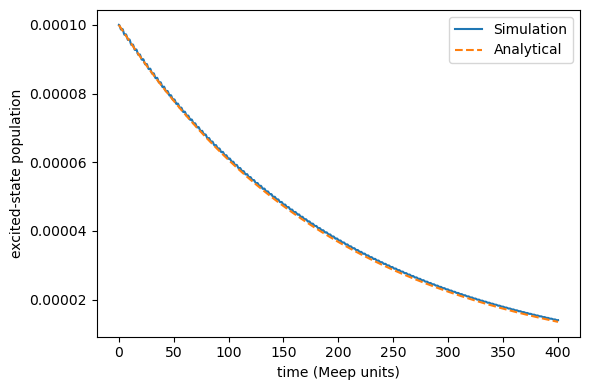

In [6]:
time_fs = time_au * 0.02418884254
time_meep = time_fs / 0.1
initial = population[0]
dipole_moment = 0.1 # meep units of mu12
frequency = 1.0 # meep units of omega

# analytical golden-rule decay rate
gamma = dipole_moment**2 * frequency**2 / 2.0

# simple exponential decay reference
reference = initial * np.exp(-time_meep * gamma)

# below is a more accurate reference which works under any initial population
#reference = np.exp(-time_meep * gamma) / (
#    np.exp(-time_meep * gamma) + (1.0 - initial) / initial
#)

std_rel = np.std(population - reference) / initial
max_rel = np.max(np.abs(population - reference)) / initial
print(f"std_dev={std_rel:.3e}, max_abs_diff={max_rel:.3e}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(time_meep, population, label="Simulation")
plt.plot(time_meep, reference, label="Analytical", linestyle="--")
plt.xlabel("time (Meep units)")
plt.ylabel("excited-state population")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Spontaneous emission in 3D vacuum

We next extend the above calculation to 3D vacuum. Here, we will use `polarization_type="transverse"` for the molecular polarization distribution, so that the spontaneous emission decay becomes smooth in 3D.

As in the 2D calculation, we first create a new TCP `SocketHub`. Then, we bind a 3D `Molecule` and a 3D Meep simulation to this hub.

In [7]:
host_3d, port_3d = mxs.get_available_host_port()
hub_3d = mxl.SocketHub(
    host=host_3d, port=port_3d, timeout=10.0, latency=1e-5
)

molecule_3d = mxl.Molecule(
    hub=hub_3d,
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(1, 1, 1),
    sigma=0.1,
    dimensions=3,
    resolution=10,
    polarization_type="transverse",
)

sim_3d = mxl.MeepSimulation(
    hub=hub_3d,
    molecules=[molecule_3d],
    cell_size=mp.Vector3(3, 3, 3),
    boundary_layers=[mp.PML(1.0)],
    resolution=10,
    time_units_fs=0.1,
)

print(f"3D SocketHub listening on {host_3d}:{port_3d}")

[Init Molecule] Under socket mode, registered molecule with ID 0


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1 eV photon energy to rotational frequency f = 2.4169E-02 mu
 - Electric field [E]: 1 mu = 6.6486E+07 V/m = 1.2930E-04 a.u.

 Given the simulation resolution = 10,
 - FDTD dt = 5.0000E-02 mu (0.5/r

We then launch a new TLS driver for the 3D calculation. The transition dipole is oriented along the $z$ direction (`orientation=2`).

In [8]:
def launch_tls_driver_3d(host, port, sleep_time=0.5):
    executable = shutil.which("mxl_driver")
    if executable is None:
        raise RuntimeError("mxl_driver executable not found in PATH.")
    cmd = (
        f"{executable} --model tls --address {host} --port {port}"
        f' --param "omega=0.484, mu12=187, orientation=2, pe_initial=0.1"'
    )
    print("Launching TLS driver via subprocess...")
    print("  " + cmd)
    proc = subprocess.Popen(shlex.split(cmd))
    time.sleep(sleep_time)
    return proc


launch_tls_driver_3d(host_3d, port_3d)
sim_3d.run(until=400)

time_au_3d = np.real(molecule_3d.extra["time_au"])
population_3d = np.real(molecule_3d.extra["Pe"])

Launching TLS driver via subprocess...
  /opt/homebrew/Caskroom/miniconda/base/envs/mxl/bin/mxl_driver --model tls --address 127.0.0.1 --port 50090 --param "omega=0.484, mu12=187, orientation=2, pe_initial=0.1"
-----------
Initializing structure...
time for choose_chunkdivision = 0.000124 s
Working in 3D dimensions.
Computational cell is 3 x 3 x 3 with resolution 10
time for set_epsilon = 0.015205 s
-----------
[initialization] Time step in atomic units: 0.20670686667500004
[initialization] Assigned a molecular ID:[SocketHub] CONNECTED: mol 0 <- 127.0.0.1:50091
 0
init TLSModel with dt = 0.206707 a.u., molecule ID = 0
[initialization] Finished initialization for molecular ID: 0
Meep progress: 128.1/400.0 = 32.0% done in 4.0s, 8.5s to go
on time step 3380 (time=169), 0.00118365 s/step
Meep progress: 299.7/400.0 = 74.9% done in 8.0s, 2.7s to go
on time step 6796 (time=339.8), 0.00117129 s/step
run 0 finished at t = 400.0 (8000 timesteps)
Received STOP, exiting
[SocketHub] DISCONNECTED: m

## 7. Compare the 3D calculation with the Golden-Rule Decay

In the same dimensionless Meep units used for the 2D comparison, the 3D vacuum golden-rule rate is (in MEEP units)

$$
k_{\rm 3D}=\frac{|\mu_{12}|^2\omega^3}{3\pi}.
$$


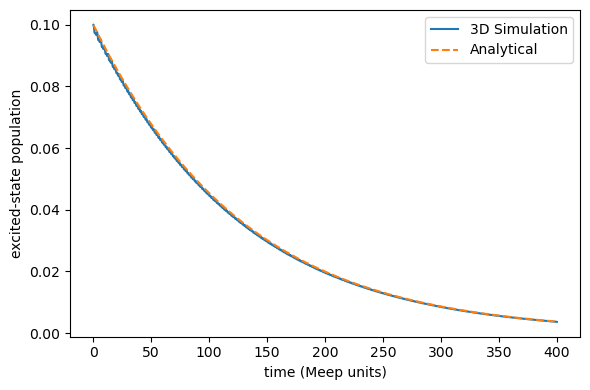

In [9]:
time_fs_3d = time_au_3d * 0.02418884254
time_meep_3d = time_fs_3d / 0.1
initial_3d = population_3d[0]
dipole_moment_3d = 0.1
frequency_3d = 2.0

gamma_3d = dipole_moment_3d**2 * frequency_3d**3 / (3.0 * np.pi)
decay_3d = np.exp(-gamma_3d * time_meep_3d)
reference_3d = decay_3d / (
    decay_3d + (1.0 - initial_3d) / initial_3d
)

plt.figure(figsize=(6, 4))
plt.plot(time_meep_3d, population_3d, label="3D Simulation")
plt.plot(
    time_meep_3d,
    reference_3d,
    label="Analytical",
    linestyle="--",
)
plt.xlabel("time (Meep units)")
plt.ylabel("excited-state population")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Reduce the computational cost with cylindrical coordinates

The above 3D EM field with a $z$-oriented dipole is rotationally symmetric. Therefore, MaxwellLink can reproduce the above 3D calculation in cylindrical coordinates using the $m=0$ angular sector.

With cylindrical coordinates, this calculation only requires a 2D $(r,z)$ grid, so the computational cost can be significantly reduced. Note that the public `Molecule.center` and `Molecule.size` retain the same Cartesian `(x, y, z)` definitions as in 3D; only the Meep simulation cell uses native cylindrical `(r, \phi, z)` coordinates. 

In [10]:
host_cyl, port_cyl = mxs.get_available_host_port()
hub_cyl = mxl.SocketHub(
    host=host_cyl, port=port_cyl, timeout=10.0, latency=1e-5
)

molecule_cyl = mxl.Molecule(
    hub=hub_cyl,
    # Molecule center and size use the same Cartesian definitions as in 3D
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(1.0, 1.0, 1.0),
    sigma=0.1,
    # dimensions=mp.CYLINDRICAL is required for the cylindrical simulation
    dimensions=mp.CYLINDRICAL,
    # It is better to increase resolution to improve cylindrical integral accuracy
    resolution=20,
    polarization_type="transverse",
)

sim_cyl = mxl.MeepSimulation(
    hub=hub_cyl,
    molecules=[molecule_cyl],
    # Meep cell_size is native (r, phi, z); r=3 adds radial padding
    # because cylindrical Meep uses a less accurate curved radial PML
    cell_size=mp.Vector3(3, 0, 3),
    boundary_layers=[mp.PML(1.0)],
    resolution=20,
    time_units_fs=0.1,
    # dimensions=mp.CYLINDRICAL is required for the cylindrical simulation
    dimensions=mp.CYLINDRICAL,
    # this m=0 is needed for the cylindrical simulation 
    m=0
)

print(f"Cylindrical SocketHub listening on {host_cyl}:{port_cyl}")

[Init Molecule] Under socket mode, registered molecule with ID 0


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1 eV photon energy to rotational frequency f = 2.4169E-02 mu
 - Electric field [E]: 1 mu = 6.6486E+07 V/m = 1.2930E-04 a.u.

 Given the simulation resolution = 20,
 - FDTD dt = 2.5000E-02 mu (0.5/r

Launching TLS driver via subprocess...
  /opt/homebrew/Caskroom/miniconda/base/envs/mxl/bin/mxl_driver --model tls --address 127.0.0.1 --port 50108 --param "omega=0.484, mu12=187, orientation=2, pe_initial=0.1"
-----------
Initializing structure...
time for choose_chunkdivision = 4.3e-05 s
Working in Cylindrical dimensions.
Computational cell is 3 x 0 x 3 with resolution 20
time for set_epsilon = 0.001063 s
-----------
[SocketHub] CONNECTED: mol 0 <- 127.0.0.1:50109
[initialization] Time step in atomic units: 0.10335343333750002
[initialization] Assigned a molecular ID: 0
init TLSModel with dt = 0.103353 a.u., molecule ID = 0
[initialization] Finished initialization for molecular ID: 0
Meep progress: 12.5/400.0 = 3.1% done in 4.0s, 124.0s to go
on time step 1772 (time=44.3), 0.00225747 s/step
Meep progress: 56.800000000000004/400.0 = 14.2% done in 8.0s, 48.3s to go
on time step 3528 (time=88.2), 0.00227856 s/step
Meep progress: 100.85000000000001/400.0 = 25.2% done in 12.0s, 35.6s to g

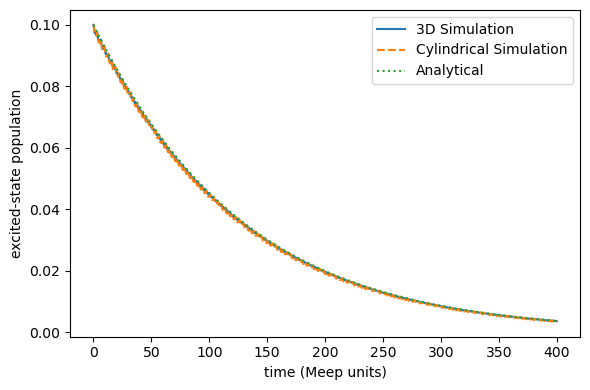

In [11]:
launch_tls_driver_3d(host_cyl, port_cyl)
sim_cyl.run(until=400)

time_au_cyl = np.real(molecule_cyl.extra["time_au"])
time_fs_cyl = time_au_cyl * 0.02418884254
time_meep_cyl = time_fs_cyl / 0.1
population_cyl = np.real(molecule_cyl.extra["Pe"])

# The two resolutions have different time steps, so compare at common times
overlap_3d = (time_meep_3d >= time_meep_cyl[0]) & (
    time_meep_3d <= time_meep_cyl[-1]
)
population_cyl_on_3d = np.interp(
    time_meep_3d[overlap_3d], time_meep_cyl, population_cyl
)
relative_difference = np.max(
    np.abs(population_3d[overlap_3d] - population_cyl_on_3d)
) / initial_3d
print(f"maximum 3D/cylindrical difference: {relative_difference:.3e}")

plt.figure(figsize=(6, 4))
plt.plot(time_meep_3d, population_3d, label="3D Simulation")
plt.plot(
    time_meep_cyl,
    population_cyl,
    label="Cylindrical Simulation",
    linestyle="--",
)
plt.plot(
    time_meep_3d,
    reference_3d,
    label="Analytical",
    linestyle=":",
)
plt.xlabel("time (Meep units)")
plt.ylabel("excited-state population")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Use an $x$-oriented TLS in cylindrical coordinates

In cylindrical coordinates, the computation also supports the use of $x$-polarized or $y$-polarized polarization density. However, because the $x$- or $y$-polarized density exhibits no cylindrical symmetry, we have to set $m=1$ (or $m=-1$). 

Additionally, the ``transverse`` polarization density is currently not supported in this parameter limit. As a result, the simulated decay dynamics trajectory is not smooth.

In [ ]:
host_cyl_x, port_cyl_x = mxs.get_available_host_port()
hub_cyl_x = mxl.SocketHub(
    host=host_cyl_x, port=port_cyl_x, timeout=10.0, latency=1e-5
)

molecule_cyl_x = mxl.Molecule(
    hub=hub_cyl_x,
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(1.0, 1.0, 1.0),
    sigma=0.1,
    dimensions=mp.CYLINDRICAL,
    resolution=20,
)

sim_cyl_x = mxl.MeepSimulation(
    hub=hub_cyl_x,
    molecules=[molecule_cyl_x],
    cell_size=mp.Vector3(3, 0, 3),
    boundary_layers=[mp.PML(1.0)],
    resolution=20,
    time_units_fs=0.1,
    dimensions=mp.CYLINDRICAL,
    m=1,
)

print(f"Cylindrical x-dipole SocketHub listening on {host_cyl_x}:{port_cyl_x}")


def launch_tls_driver_cyl_x(host, port, sleep_time=0.5):
    executable = shutil.which("mxl_driver")
    if executable is None:
        raise RuntimeError("mxl_driver executable not found in PATH.")
    cmd = (
        f"{executable} --model tls --address {host} --port {port}"
        f' --param "omega=0.484, mu12=187, orientation=0, pe_initial=0.1"'
    )
    print("Launching x-oriented TLS driver via subprocess...")
    print("  " + cmd)
    proc = subprocess.Popen(shlex.split(cmd))
    time.sleep(sleep_time)
    return proc


launch_tls_driver_cyl_x(host_cyl_x, port_cyl_x)
sim_cyl_x.run(until=400)

[Init Molecule] Under socket mode, registered molecule with ID 0


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1 eV photon energy to rotational frequency f = 2.4169E-02 mu
 - Electric field [E]: 1 mu = 6.6486E+07 V/m = 1.2930E-04 a.u.

 Given the simulation resolution = 20,
 - FDTD dt = 2.5000E-02 mu (0.5/r

maximum 3D/cylindrical x-dipole difference: 2.245e-01


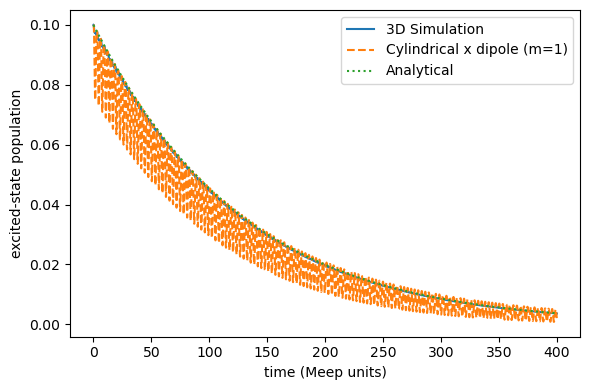

In [ ]:
time_au_cyl_x = np.real(molecule_cyl_x.extra["time_au"])
time_fs_cyl_x = time_au_cyl_x * 0.02418884254
time_meep_cyl_x = time_fs_cyl_x / 0.1
population_cyl_x = np.real(molecule_cyl_x.extra["Pe"])

# Compare the m=1 result with the existing 3D population at common times
overlap_3d_cyl_x = (time_meep_3d >= time_meep_cyl_x[0]) & (
    time_meep_3d <= time_meep_cyl_x[-1]
)
population_cyl_x_on_3d = np.interp(
    time_meep_3d[overlap_3d_cyl_x], time_meep_cyl_x, population_cyl_x
)

plt.figure(figsize=(6, 4))
plt.plot(time_meep_3d, population_3d, label="3D Simulation")
plt.plot(
    time_meep_cyl_x,
    population_cyl_x,
    label="Cylindrical x dipole (m=1)",
    linestyle="--",
)
plt.plot(
    time_meep_3d,
    reference_3d,
    label="Analytical",
    linestyle=":",
)
plt.xlabel("time (Meep units)")
plt.ylabel("excited-state population")
plt.legend()
plt.tight_layout()
plt.show()